# Task 4.1 실행 모드 시연 (Demonstrate execution Modes)

**개요 (Overview):** 이 노트북은 Qiskit에서 사용 가능한 실행 모드 (execution modes) 에 대해 다룹니다. 또한 다음 내용들을 포함합니다:

*   하드웨어에서의 **실행 단계 (Execution steps)**.
*   **실행 모드 (Execution modes)** (job, batch, session) 와 각 모드의 사용 시기.
*   **일괄 실행 (Batch execution)** 및 배치를 열고 닫는 방법, 제한 설정 방법.


- [Execution Mode](https://quantum.cloud.ibm.com/docs/en/guides/execution-modes)
- [run job batch](https://quantum.cloud.ibm.com/docs/en/guides/run-jobs-batch)
- [REST API](https://quantum.cloud.ibm.com/docs/en/guides/execution-modes-rest-api)

In [62]:
import qiskit
import qiskit_ibm_runtime
print(qiskit.__version__)
print(qiskit_ibm_runtime.__version__)

2.1.2
0.45.0


In [63]:
# Setup: Import necessary libraries
from qiskit_ibm_runtime import QiskitRuntimeService,Batch, SamplerV2 as Sampler, EstimatorV2 as Estimator
from qiskit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.random import random_circuit


print("Libraries imported successfully.")

Libraries imported successfully.


## 목표 1: 하드웨어에서 실행 (Execute on hardware)

실제 하드웨어에서 양자 회로를 실행하는 과정은 여러 단계로 구성됩니다:

1. **인증 (Authentication)**: IBM Quantum Runtime 서비스에 연결합니다.
2. **백엔드 선택 (Backend Selection)**: 사용 가능한 양자 프로세서를 선택합니다.
3. **회로 준비 (Circuit Preparation)**: 특정 하드웨어 제약 조건에 맞춰 회로를 트랜스파일 (transpiling) 합니다.
4. **작업 제출 (Job Submission)**: 실행을 위해 회로를 전송합니다.
5. **결과 검색 (Result Retrieval)**: 측정 결과를 얻고 분석합니다.

## 목표 2: 실행 모드 (Execution modes)

### 세 가지 실행 모드 (Three Execution Modes)

IBM Quantum은 양자 프로그램을 실행하기 위한 세 가지 고유한 실행 모드 (execution modes) 를 제공합니다:

1. **작업 모드 (Job Mode)** (`mode=backend`)
   - 컨텍스트 매니저 (context manager) 없이 Sampler 또는 Estimator를 단일 요청으로 실행합니다.
   - 일회성 실행을 위한 가장 간단한 모드입니다.
   - 프리미티브 (primitive) 를 초기화할 때 `mode=backend`를 지정합니다.

2. **일괄 모드 (Batch Mode)** (`mode=batch`)
   - 서로 조건부 관계가 없는, 독립적으로 실행 가능한 여러 작업으로 구성된 워크로드입니다.
   - 효율성을 위해 작업들이 함께 스케줄링됩니다.
   - 제출된 순서대로 실행되는 것이 보장되지 않으며, 다른 사용자의 작업과 병렬로 실행될 수 있습니다. 또한 배치 작업 사이에 QPU 캘리브레이션 (calibration) 작업이 실행될 수도 있습니다.
   - 첫 번째 제출된 작업의 대기 시간은 줄어들지 않습니다.
   - 프리미티브를 초기화할 때 `mode=batch`를 지정합니다.

3. **세션 모드 (Session Mode)** (`mode=session`)
   - 여러 작업으로 구성된 워크로드를 실행하기 위한 전용 창 (window) 입니다.
   - QPU에 대한 독점적인 액세스 권한을 가지며, 캘리브레이션 작업을 포함한 다른 작업이 실행될 수 없습니다.
   - 고전 리소스와 양자 리소스 간의 빈번한 통신이 필요한 반복 작업 (iterative tasks) 에 특히 유용합니다.
   - 첫 번째 제출된 작업의 대기 시간은 줄어들지 않습니다.
   - 프리미티브를 초기화할 때 `mode=session`을 지정합니다.

## 목표 3: 실행 모드 선택 (Choose execution mode)

<img src="https://quantum.cloud.ibm.com/docs/images/guides/execution-modes/batch@dark.svg" width="300">
<img src="https://quantum.cloud.ibm.com/docs/images/guides/execution-modes/session@dark.svg" width="300">


### 각 모드 사용 시기 (When to Use Each Mode)

| 모드 (Mode) | 적합한 작업 | 주요 기능 |
|------|----------|-------------|
| **배치 (Batch)** | 독립적인 대규모 회로 모음 | • 전체 배치가 함께 스케줄링됨<br>• 고전적 계산이 병렬로 실행됨<br>• 작업 간 지연 최소화<br>• 유연성 - 필요 시 남은 작업 취소 가능<br>• 세션보다 저렴함 |
| **세션 (Session)** | 변분 알고리즘, 반복적 워크로드 | • 모든 Batch 모드 기능 포함<br>• QPU에 대한 독점적 액세스<br>• 입력이 점진적으로 도착할 때 유용<br>• 낮은 대기 시간이 필요한 워크로드에 적합 |
| **작업 (Job)** | 소규모 실험, 빠른 테스트 | • 가장 단순한 인터페이스<br>• Batch보다 빨리 실행될 수 있음<br>• 학습 및 테스트용으로 좋음 |

### 권장 사항 (Best Practices)

- 특히 모든 입력이 준비된 경우 기본적으로 일괄 모드 (Batch mode) 를 사용하십시오. 세션보다 비용 효율적입니다.

- 일괄 모드는 총 실행 시간을 줄이기 위해 여러 프리미티브 작업을 한 번에 제출할 때 이상적입니다.

- 세션 모드 (Session mode) 는 반복적인 워크플로우나 전용 QPU 액세스가 필요한 경우에 가장 적합하지만, 일반적으로 더 비쌉니다.

- 작업 모드 (Job mode) 는 단일 프리미티브 요청에만 사용해야 합니다.

- 오픈 플랜 (Open Plan) 사용자는 세션을 사용할 수 없습니다.

### 추천 사항 (Recommendations):

- 각 작업에는 고정된 오버헤드가 있습니다. 작업이 1분 미만의 QPU 시간을 사용하는 경우 여러 태스크를 단일 작업으로 결합하십시오.

- 작업이 1분 이상 걸리거나 결합할 수 없는 경우, QPU가 한 번에 하나의 작업을 실행하더라도 병렬 고전 처리(최대 5개 작업)를 활용하기 위해 일괄 또는 세션 모드로 여러 작업을 제출하십시오.

- 특히 세션에서는 실행 시간과 비용을 최소화하기 위해 워크로드 크기와 병렬성을 조정하십시오. 큰 작업을 나누는 것이 더 효율적일 수 있습니다.

## 목표 4: 배치로 작업 실행 (Run Jobs in Batch)

### 일괄 실행의 기본 (Batch Execution Fundamentals)

일괄 모드 (Batch mode) 를 사용하면 함께 스케줄링되는 여러 양자 작업을 제출할 수 있습니다. 이는 개별 작업을 따로 제출하는 것보다 효율적입니다.

In [64]:
# if your account is already saved, this will load it
# service = QiskitRuntimeService(name="YONSEI")
service = QiskitRuntimeService(name="OPEN")

# replace <instance_name> with your instance name
# replace <token> with your IBM Quantum API token
# Uncomment and use the following line if you need to specify instance and token
# srvice = QiskitRuntimeService(channel="ibm_cloud",instance="<instance_name>",token=<token>)


### 배치 열기 (Open a batch)

Batch 클래스를 초기화하거나 컨텍스트 매니저 (Context Manager) `with Batch()`를 사용하여 수행할 수 있습니다.

In [65]:
# Method 1: Explicit batch creation and closure
# backend = service.least_busy(operational=True, simulator=False)
backend = service.backend("ibm_marrakesh")

print(f"Selected backend: {backend.name}")

#Create a batch execution context
batch = Batch(backend=backend, max_time="5m")

# Configure primitives to use batch mode
estimator = Estimator(mode=batch)
sampler = Sampler(mode=batch)

# Close the batch explicitly (no context manager used)
batch.close()

Selected backend: ibm_marrakesh


In [66]:
# Method 2: Using context manager
backend = service.least_busy(operational=True, simulator=False)
print(f"Selected backend: {backend.name}")
# Automatically handle batch lifecycle
with Batch(backend=backend, max_time="5m"):
    estimator = Estimator()  
    sampler = Sampler()

#Batch automatically closes when context exits

Selected backend: ibm_fez


배치로 실행할 회로 준비

In [67]:
# Create example circuits and observables
qc1 = QuantumCircuit(2)
qc1.h(0)
qc1.cx(0, 1)
qc1.measure_all()

qc2 = QuantumCircuit(2)
qc2.h(0)
qc2.cx(0, 1)
qc2.rz(0.5, 1)
qc2.measure_all()

# Create observables for estimator
observable1 = SparsePauliOp("Z"*backend.num_qubits) 
observable2 = SparsePauliOp("X"*backend.num_qubits)

pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
isa_circuit1 = pm.run(qc1)
isa_circuit2 = pm.run(qc2)
# Create primitive units (pubs) for execution
estimator_pub = (isa_circuit1, observable1)
sampler_pub = isa_circuit2

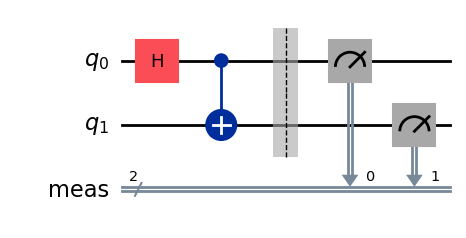

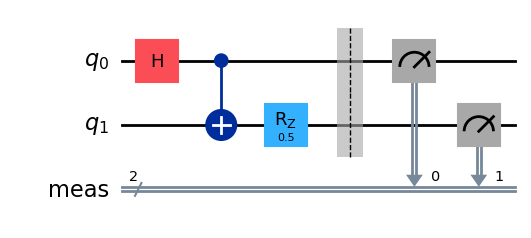

In [55]:
display(qc1.draw("mpl"))
display(qc2.draw("mpl"))

#### 배치 기간 제한 (Batch Duration Limits)

최대 수명 (max TTL) 은 `max_time`으로 정의할 수 있으며, 작업 배치가 시작될 때 시작됩니다. 최대 시간에 도달하면 배치가 닫히고 실행 중인 작업은 완료되지만 대기 중인 모든 작업은 실패합니다.

| 요금제 유형 (Plan Type) | 최대 배치 기간 (Maximum Batch Duration) |
|-----------|-----------------------|
| 오픈 플랜 (Open Plan) | 10분 |
| 유료 플랜 (Paid Plans) | 8시간 |

또한 구성할 수 없는 대화형 TTL (interactive TTL) 이 있습니다 (모든 플랜에 대해 1분). 해당 시간 동안 큐에 작업이 없으면 작업이 일시적으로 비활성화됩니다.

**참고:** 이 제한은 배치 내 모든 작업의 총 실행 시간에 적용됩니다.

### 배치 닫기 (Close a batch)

배치는 컨텍스트 매니저가 종료될 때 자동으로 닫힙니다. 그 후 배치는 새 작업 접수를 중단하고, 최대 TTL에 도달할 때까지 대기 중이거나 진행 중인 모든 작업을 완료한 뒤 영구적으로 닫힙니다.

컨텍스트 매니저를 사용하지 않는 경우 배치를 수동으로 닫아야 합니다. 배치를 열어두고 나중에 작업을 제출하면 작업을 시작하기 전에 최대 TTL에 도달하여 취소될 위험이 있습니다. `batch.close()`를 호출하면 새 제출을 방지하는 동시에 이미 제출된 작업은 완료되고 결과를 얻을 수 있도록 합니다.

<span style="color:red"> **아래 셀을 실행하면 IBM 계정 크레딧에서 약 10-15초가 소요됩니다.** </span>

In [69]:
# with Batch(backend=backend) as batch:
#     estimator = Estimator()
#     sampler = Sampler()
#     job1 = estimator.run([estimator_pub])
#     job2 = sampler.run([sampler_pub])
 
# The batch is no longer accepting jobs but the submitted job will run to completion.

job1 = service.job('d7apbse5nvhs73a2d0eg')
job2 = service.job('d7apbsr0g7hs73dokr1g')
result = job1.result()
result2 = job2.result()

In [73]:
result[0].data

DataBin(evs=np.ndarray(<shape=(), dtype=float64>), stds=np.ndarray(<shape=(), dtype=float64>), ensemble_standard_error=np.ndarray(<shape=(), dtype=float64>))

In [70]:
print(result[0].data.evs)
print(result2[0].data.meas.get_counts())

0.0146484375
{'00': 2041, '11': 1980, '10': 39, '01': 36}


In [74]:
# This will raise an error since the batch is closed
job3 = sampler.run([sampler_pub])

IBMRuntimeError: 'The session is closed.'

### 배치 정보 및 모니터링 (Batch Information and Monitoring)

In [75]:
# Get batch details for monitoring
with Batch(backend=backend) as batch:
    details = batch.details()
    
print("Batch Details:")
print(f"ID: {details['id']}")
print(f"Backend: {details['backend_name']}")
print(f"State: {details['state']}")
print(f"Max Time: {details['max_time']} seconds")
print(f"Accepting Jobs: {details['accepting_jobs']}")
print(f"Mode: {details['mode']}")

Batch Details:
ID: 95e77f37-a30d-40fa-80be-d8c0920bc86f
Backend: ibm_fez
State: open
Max Time: 600 seconds
Accepting Jobs: True
Mode: batch


### 대규모 회로 배치 처리 (Handling Large Batches of Circuits)

<span style="color:red"> **아래 셀을 실행하면 IBM 계정 크레딧에서 약 1분 정도 소요됩니다. 회로 수를 줄여 실행 시간을 단축할 수 있습니다.** </span>


In [53]:
# Create a large number of circuits
max_circuits_per_batch = 10  # Limit per batch submission
total_circuits = 50
circuits = [random_circuit(3, 3) for _ in range(total_circuits)]

# Partition circuits into manageable batches
all_partitioned_circuits = []
for i in range(0, len(circuits), max_circuits_per_batch):
    all_partitioned_circuits.append(circuits[i : i + max_circuits_per_batch])

jobs = []

# Submit partitioned batches
with Batch(backend=backend):
    sampler = Sampler()
    for i, partitioned_circuits in enumerate(all_partitioned_circuits):
        pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
        isa_circuit = pm.run(partitioned_circuits)
        job = sampler.run(isa_circuit)
        jobs.append(job)
        print(f"Submitted batch {i+1} with {len(partitioned_circuits)} circuits")

print(f"\nCreated {total_circuits} circuits")
print(f"Partitioned into {len(all_partitioned_circuits)} batches of maximum {max_circuits_per_batch} circuits each")
print(f"Successfully submitted {len(jobs)} jobs to batch")

/Users/jojeongbin/miniforge3/lib/python3.12/site-packages/qiskit_ibm_runtime/utils/validations.py:42: UserWarning: The 0-th circuit has no output classical registers so the result will be empty. Did you mean to add measurement instructions?
  warnings.warn(
/Users/jojeongbin/miniforge3/lib/python3.12/site-packages/qiskit_ibm_runtime/utils/validations.py:42: UserWarning: The 1-th circuit has no output classical registers so the result will be empty. Did you mean to add measurement instructions?
  warnings.warn(
/Users/jojeongbin/miniforge3/lib/python3.12/site-packages/qiskit_ibm_runtime/utils/validations.py:42: UserWarning: The 2-th circuit has no output classical registers so the result will be empty. Did you mean to add measurement instructions?
  warnings.warn(
/Users/jojeongbin/miniforge3/lib/python3.12/site-packages/qiskit_ibm_runtime/utils/validations.py:42: UserWarning: The 3-th circuit has no output classical registers so the result will be empty. Did you mean to add measurement

Submitted batch 1 with 10 circuits
Submitted batch 2 with 10 circuits
Submitted batch 3 with 10 circuits
Submitted batch 4 with 10 circuits
Submitted batch 5 with 10 circuits

Created 50 circuits
Partitioned into 5 batches of maximum 10 circuits each
Successfully submitted 5 jobs to batch


### 세션 테스트

<span style="color:red"> **아래 코드는 Open Plan에서는 실행이 어렵습니다.** </span>


In [76]:
# Load the Qiskit Runtime service
from qiskit_ibm_runtime import QiskitRuntimeService

# Load the Runtime primitive and session
from qiskit_ibm_runtime import EstimatorV2 as Estimator

# Syntax for first saving your token.  Delete these lines after saving your credentials.
# QiskitRuntimeService.save_account(channel='ibm_quantum_platform', instance = '<YOUR_IBM_INSTANCE_CRN>', token='<YOUR-API_KEY>', overwrite=True, set_as_default=True)
# service = QiskitRuntimeService(channel='ibm_quantum_platform')

# Load saved credentials
service = QiskitRuntimeService()

# Use the least busy backend, or uncomment the loading of a specific backend like "ibm_brisbane".
backend = service.least_busy(operational=True, simulator=False, min_num_qubits=127)
# backend = service.backend("ibm_brisbane")
print(backend.name)

ibm_yonsei


In [78]:
# Load the Aer simulator and generate a noise model based on the currently-selected backend.
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel

# Alternatively, load a fake backend with generic properties and define a simulator.


noise_model = NoiseModel.from_backend(backend)

# Define a simulator using Aer, and use it in Sampler.
backend_sim = AerSimulator(noise_model=noise_model)
print(backend_sim)

AerSimulator('aer_simulator'
             noise_model=<NoiseModel on ['id', 'measure', 'reset', 'ecr', 'sx', 'x']>)


In [79]:
from qiskit.quantum_info import SparsePauliOp
import numpy as np

# Qubit Hamiltonian of the hydrogen atom generated by using STO-3G basis set and parity mapping
Hamiltonian = SparsePauliOp.from_list([("I", -0.2355), ("Z", 0.2355)])

# exact ground state energy of Hamiltonian

A = np.array(Hamiltonian)
eigenvalues, eigenvectors = np.linalg.eig(A)
print(
    "The exact ground state energy of the Hamiltonian is ",
    min(eigenvalues).real,
    "hartree",
)
h = min(eigenvalues.real)

The exact ground state energy of the Hamiltonian is  -0.471 hartree


In [83]:
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.quantum_info import Statevector, DensityMatrix, Pauli

theta = Parameter(r"$\theta$")
phi = Parameter(r"$\phi$")
lam = Parameter(r"$\lambda$")


ansatz = QuantumCircuit(1)
ansatz.rx(theta, 0)
ansatz.rz(phi, 0)
ansatz.rx(lam, 0)

This circuit has  3 parameters


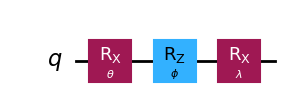

In [84]:
# Pre-defined ansatz circuit and operator class for Hamiltonian
num_params = ansatz.num_parameters
print("This circuit has ", num_params, "parameters")

ansatz.draw("mpl", style="iqp")

Backend: {config.backend_name}
Native gates:  ['store', 'id', 'if_else', 'acquire', 'u1', 'reset', 'setf', 'shiftf', 'sx', 'delay', 'measure', 'play', 'ecr', 'x', 'rz'] ,


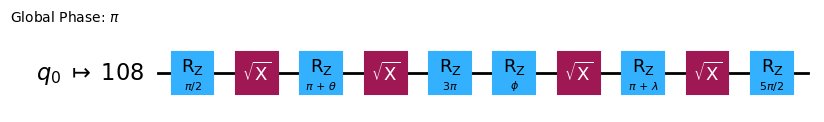

In [86]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

config = backend.configuration()

print("Backend: {config.backend_name}")
print("Native gates: ", config.supported_instructions, ",")

pm = generate_preset_pass_manager(target=backend.target, optimization_level=3)

ansatz_isa = pm.run(ansatz)

ansatz_isa.draw(output="mpl", idle_wires=False, style="iqp")

In [87]:
Hamiltonian_isa = Hamiltonian.apply_layout(layout=ansatz_isa.layout)

In [88]:
def cost_func(params, ansatz, hamiltonian, estimator):
    """Return estimate of energy from estimator

    Parameters:
        params (ndarray): Array of ansatz parameters
        ansatz (QuantumCircuit): Parameterized ansatz circuit
        hamiltonian (SparsePauliOp): Operator representation of Hamiltonian
        estimator (EstimatorV2): Estimator primitive instance
        cost_history_dict: Dictionary for storing intermediate results

    Returns:
        float: Energy estimate
    """
    pub = (ansatz, [hamiltonian], [params])
    result = estimator.run(pubs=[pub]).result()
    energy = result[0].data.evs[0]

    cost_history_dict["iters"] += 1
    cost_history_dict["prev_vector"] = params
    cost_history_dict["cost_history"].append(energy)
    print(f"Iters. done: {cost_history_dict['iters']} [Current cost: {energy}]")

    return energy

In [ ]:
from scipy.optimize import minimize
from qiskit_ibm_runtime import Batch, Session

# x0 = np.random.uniform(0, 2*pi, 3)
x0 = [1, 1, 0]
session = Session(backend=backend_sim) # 현재는 simulator로 설정. 
# 필요시 real backend로 바꿀 수 있음(openplan)에서는 불가능

cost_history_dict = {
    "prev_vector": None,
    "iters": 0,
    "cost_history": [],
}
estimator = Estimator(mode=session)
estimator.options.default_shots = 10000

res = minimize(
    cost_func,
    x0,
    args=(ansatz_isa, Hamiltonian_isa, estimator),
    method="cobyla",
    options={"maxiter": 10, "tol": 0.01},
)

session.close()

Iters. done: 1 [Current cost: -0.11167409999999998]
Iters. done: 2 [Current cost: -0.332997]
Iters. done: 3 [Current cost: -0.3269682]
Iters. done: 4 [Current cost: -0.38127449999999996]
Iters. done: 5 [Current cost: -0.334881]
Iters. done: 6 [Current cost: -0.3660612]
Iters. done: 7 [Current cost: -0.4004442]
Iters. done: 8 [Current cost: -0.4314831]
Iters. done: 9 [Current cost: -0.45300779999999996]
Iters. done: 10 [Current cost: -0.4524897]


In [97]:
h_vqe = res.fun
print("The reference ground state energy is ", min(eigenvalues))
print("The computed ground state energy is ", h_vqe)

The reference ground state energy is  (-0.471+0j)
The computed ground state energy is  -0.45300779999999996


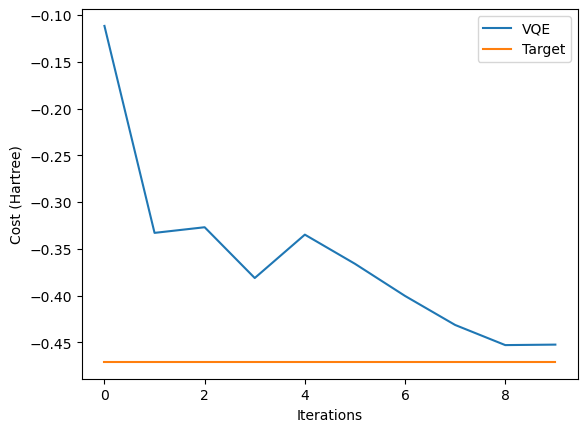

In [98]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
x = np.linspace(0, 10, 10)

# Define the constant function
y_constant = np.full_like(x, h)
ax.plot(
    range(cost_history_dict["iters"]), cost_history_dict["cost_history"], label="VQE"
)
ax.set_xlabel("Iterations")
ax.set_ylabel("Cost (Hartree)")
ax.plot(y_constant, label="Target")
plt.legend()
plt.draw()

---
# 요약 (Summary)
---

In this notebook, we covered:

## Execution modes:

1. **Qiskit provides three execution modes** to execute quantum programs.
2. **Job mode** is the simplest interface, and it can be used for quick tests and for learning.
3. **Batch mode** can be used for independent multi job workloads, where all jobs are scheduled together for efficiency, however there is no guarantee on execution order.
4. **Session mode** can be used for iterative tasks requriing classical and quantum communication, it provides execulsive QPU access and it is more expensive that batch mode.
5. **Batch mode** can be enabled using `Batch` class or context manager `with Batch()`.


---

## 연습 문제 (Practice Questions)

**1) 일괄 모드 (Batch mode) 대신 세션 모드 (Session mode) 를 선택하는 경우는 언제입니까?**

A) 실행해야 할 대규모의 독립 회로 모음이 있을 때.<br/>
B) 일회성 양자 작업을 위한 가장 간단한 인터페이스가 필요할 때.<br/>
C) 고전 리소스와 양자 리소스 간의 반복적인 통신이 필요한 변분 알고리즘 (variational algorithms) 을 실행할 때.<br/>
D) 오픈 플랜 계정을 사용 중이며 비용을 최소화해야 할 때.<br/>

**정답 (Answer):**
<details> <br/>

C) 고전 리소스와 양자 리소스 간의 반복적인 통신이 필요한 변분 알고리즘을 실행할 때.

세션 모드는 전용 QPU 액세스를 제공하므로 변분 양자 고윳값 솔버 (VQE) 와 같은 반복적인 워크플로우에 가장 유용합니다.

</details>

---

**2) 일괄 모드 (Batch mode) 실행의 주요 제한 사항은 무엇입니까?**

A) 배치의 작업은 다른 사용자의 작업과 병렬로 실행될 수 없습니다.<br/>
B) 작업이 제출된 순서대로 실행된다는 보장이 없습니다.<br/>
C) 오픈 플랜 사용자만 일괄 모드를 사용할 수 있습니다.<br/>
D) 일괄 모드가 세션 모드보다 비쌉니다.<br/>

**정답 (Answer):**
<details> <br/>

B) 배치의 작업은 제출 순서대로 실행되는 것이 보장되지 않으므로, 독립적으로 실행 가능한 작업에 대해서만 사용하는 것이 중요합니다.
</details>

---

**3) 이 일괄 실행 코드의 문제점은 무엇입니까?**

```
from qiskit_ibm_runtime import Batch, SamplerV2 as Sampler

# Create batch
batch = Batch(backend=backend, max_time="5m")
sampler = Sampler(mode=batch)

# Submit some jobs
job1 = sampler.run([circuit1])
job2 = sampler.run([circuit2])

# Close batch
batch.close()

# Try to submit another job
job3 = sampler.run([circuit3])

```

A) 문제가 없습니다 - 세 작업 모두 정상적으로 실행됩니다.<br/>
B) 일괄 실행을 위해 컨텍스트 매니저 (with) 를 사용해야 합니다.<br/>
C) 배치는 job3를 위해 자동으로 다시 열립니다.<br/>
D) 배치가 이미 닫혔기 때문에 job3는 실패합니다.<br/>

**정답 (Answer):**
<details> <br/>

D) 배치가 이미 닫혔기 때문에 job3는 실패합니다. 배치는 일단 닫히면 더 이상 작업을 수락하지 않습니다.
</details>

---

**4) 이 코드를 실행하는 가장 효율적인 방법은 무엇입니까?**

```
# Create 100 variations of the same circuit
circuits = []
for i in range(100):
    qc = QuantumCircuit(2)
    qc.h(0)
    qc.cx(0, 1)
    qc.rz(i * 0.01, 1)  # Small variation
    qc.measure_all()
    circuits.append(qc)

# Need to run all circuits
```

A) 작업 모드 (Job mode) 사용 - 각 회로를 `sampler.run([circuit])`으로 제출 <br/>
B) 10개 그룹으로 나누고 각 그룹에 대해 작업 모드 사용 <br/>
C) 세션 모드 (Session mode) 사용 - 세션을 생성하고 회로를 개별적으로 제출 <br/>
D) 일괄 모드 (Batch mode) 사용 - `sampler.run(circuits)`로 모든 회로를 제출 <br/>

**정답 (Answer):**
<details> <br/>

D) 회로가 독립적이므로 일괄 모드 (Batch mode) 를 사용합니다.
</details>